In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

In [2]:
# Load dataset
(x_train, _), (x_test, _) = fashion_mnist.load_data()


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# Normalize
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

In [4]:
# Flatten images
x_train = x_train.reshape((-1, 784))
x_test = x_test.reshape((-1, 784))

In [5]:
# Autoencoder
input_img = Input(shape=(784,))
encoded = Dense(64, activation='relu')(input_img)
decoded = Dense(784, activation='sigmoid')(encoded)

autoencoder = Model(input_img, decoded)

In [6]:
# BCE Loss
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

In [7]:
# Train
autoencoder.fit(
    x_train,
    x_train,
    epochs=5,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)


Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.3914 - val_loss: 0.3286
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.3142 - val_loss: 0.3062
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2977 - val_loss: 0.2943
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.2887 - val_loss: 0.2879
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.2838 - val_loss: 0.2843


In [8]:
# Reconstruction
decoded_imgs = autoencoder.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


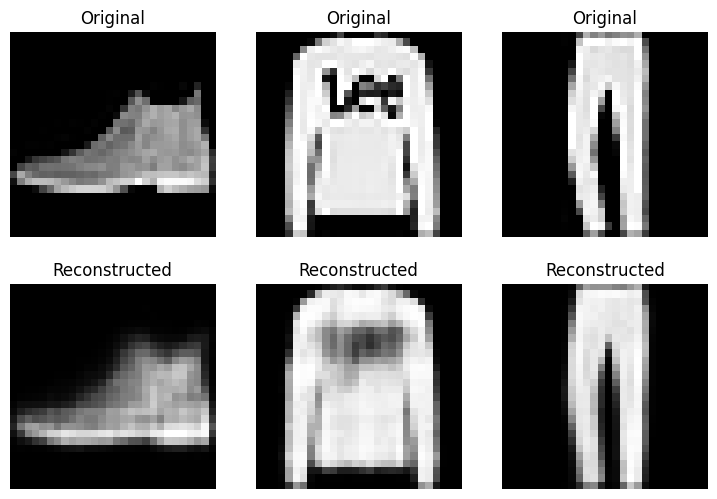

In [9]:
# Show 3 Images
plt.figure(figsize=(9, 6))

for i in range(3):
    # Original
    plt.subplot(2, 3, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    plt.subplot(2, 3, i + 4)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.show()